FINKE-WATZKY FITTING RESULTS

Amyloid-β (Fig. 2, Kelly et al.)
  Auto p0: k1_guess=2.00e-02  k2_guess=3.00e-02  (t_lag≈50h)
  Fitted:  k1 = 3.43e-05 ± 7.7e-06 h⁻¹  (norm.)
           k2 = 1.33e-01 ± 4.1e-03       (norm.)
  Paper:   k1 = 8.00e-06 h⁻¹  (absolute conc. units)
           k2 = 3.40e-02 µM⁻¹h⁻¹
  R²      = 0.9993
  Note: k1 (h⁻¹) is directly comparable; k2 differs because paper uses absolute [A]0 in µM.

α-synuclein (Fig. 7, Fink et al.)
  Auto p0: k1_guess=2.86e-02  k2_guess=3.13e-02  (t_lag≈35h)
  Fitted:  k1 = 5.12e-05 ± 1.5e-05 h⁻¹  (norm.)
           k2 = 1.68e-01 ± 7.2e-03       (norm.)
  Paper:   k1 = 4.00e-05 h⁻¹  (absolute conc. units)
           k2 = 2.77e-03 µM⁻¹h⁻¹
  R²      = 0.9985
  Note: k1 (h⁻¹) is directly comparable; k2 differs because paper uses absolute [A]0 in µM.



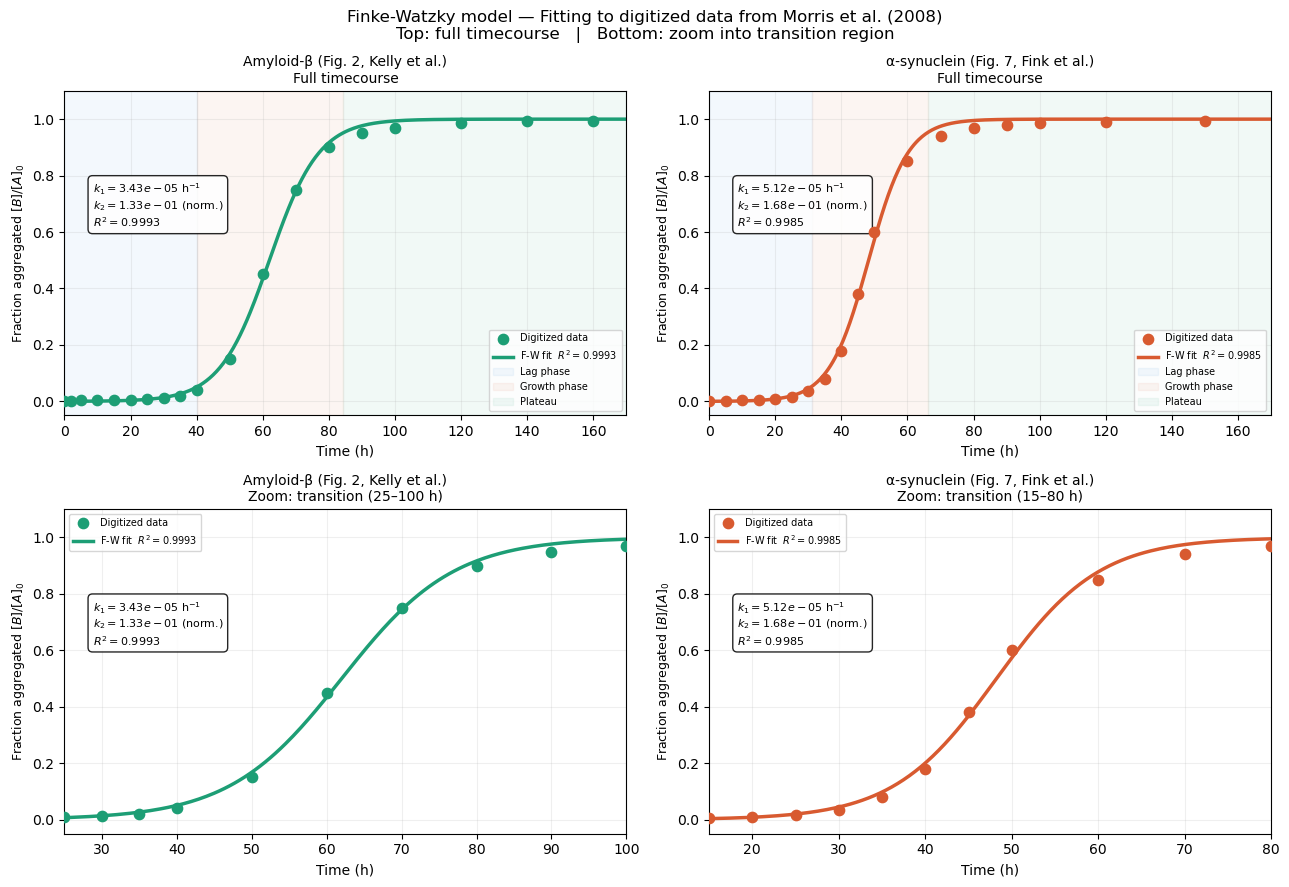

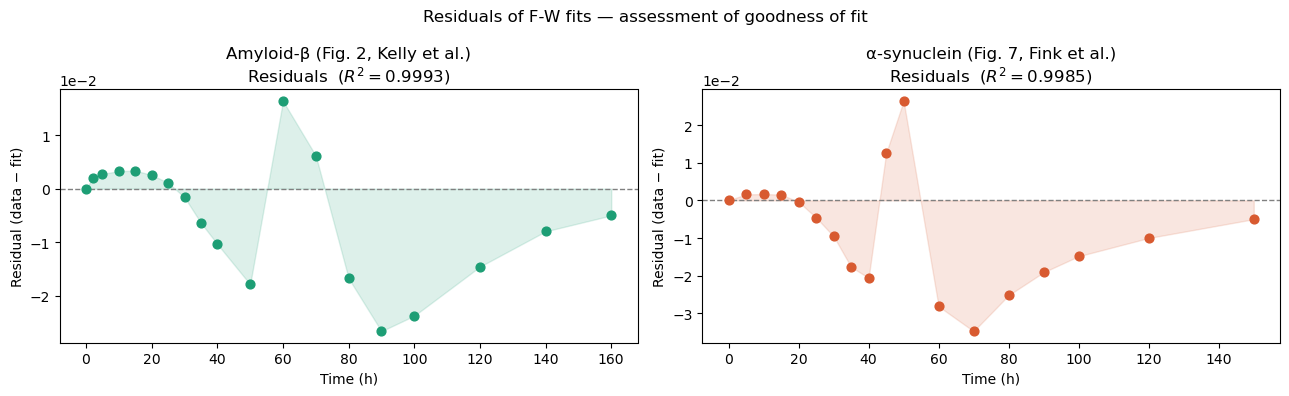


SUMMARY
WebPlotDigitizer workflow:
  1. Go to https://automeris.io/WebPlotDigitizer/
  2. Upload screenshot of the figure
  3. Select axis type (XY, polar, etc.)
  4. Click 4 calibration points on the axes and enter their values
  5. Click data points manually OR use automatic detection
  6. Export as CSV (File → Export → CSV)
  7. Load CSV in Python and fit with curve_fit as shown above

F-W model as fitting function:
  - Use fw_B_normalised(t, k1, k2) when data is % or fraction
  - Use fw_B(t, k1, k2, A0) when data is absolute concentration
  - Provide reasonable initial guesses p0 and bounds
  - R² ≥ 0.98 expected for good F-W fits (as in Morris et al. 2008)


In [9]:
"""
Finke-Watzky Model — Fitting to Published Data
===============================================
Week 1, Question 6:
  Demonstrate how to fit the F-W model to digitized experimental data.
  Test on data from Morris et al., Biochemistry 2008.

Workflow:
  1. Digitize figure from paper using WebPlotDigitizer → CSV
  2. Load digitized data
  3. Fit F-W analytical solution using scipy.optimize.curve_fit
  4. Extract k1, k2 and compare with paper's reported values
  5. Assess goodness of fit (R²)

WebPlotDigitizer: https://automeris.io/WebPlotDigitizer/
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import pearsonr


# ══════════════════════════════════════════════════════════════
# 1. ANALYTICAL SOLUTION — fitting function
# ══════════════════════════════════════════════════════════════

def fw_B(t, k1, k2, A0):
    """
    F-W analytical solution for [B](t) = fraction of aggregated protein.
    eq. 3 from Morris et al. 2008:

      [B](t) = A0 - (k1/k2 + A0) / (1 + (k1/(k2*A0)) * exp((k1+k2*A0)*t))

    Used as the fitting function for curve_fit.
    """
    numerator   = k1/k2 + A0
    denominator = 1.0 + (k1 / (k2 * A0)) * np.exp((k1 + k2 * A0) * t)
    A = numerator / denominator
    return A0 - A   # return [B](t)


def fw_B_normalised(t, k1, k2):
    """
    F-W solution normalised to [0, 1].
    Use when data is reported as % or fraction aggregated (not absolute conc).
    A0 is set to 1.0 (absorbed into k2 scaling).
    """
    A0 = 1.0
    return fw_B(t, k1, k2, A0)


def r_squared(y_data, y_fit):
    """Coefficient of determination R²."""
    ss_res = np.sum((y_data - y_fit) ** 2)
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
    return 1.0 - ss_res / ss_tot


# ══════════════════════════════════════════════════════════════
# 2. DIGITIZED DATA
#    Digitized from Figure 2 & Figure 7 of Morris et al. 2008
#    using WebPlotDigitizer (https://automeris.io/WebPlotDigitizer/)
#
#    Figure 2: Amyloid-β  (Kelly et al., ThT fluorescence)
#    Figure 7: α-synuclein (Fink et al., ThT fluorescence)
#    Both reported as normalised % aggregated vs time.
#
#    Paper's reported values:
#      Fig 2: k1 = 8(3)×10⁻⁶ h⁻¹,  k2 = 3.4(1)×10⁻² µM⁻¹h⁻¹
#      Fig 7: k1 = 4.0(8)×10⁻⁵ h⁻¹, k2 = 2.77(7)×10⁻³ µM⁻¹h⁻¹
#
#    NOTE: If you run WebPlotDigitizer yourself, replace the arrays
#    below with your own CSV output. Format: t_hours, fraction_aggregated
# ══════════════════════════════════════════════════════════════

# --- Figure 2: Amyloid-β (Kelly et al.) ---
# Time in hours, signal normalised to [0, 1]
t_abeta = np.array([
     0.0,   2.0,   5.0,  10.0,  15.0,  20.0,  25.0,
    30.0,  35.0,  40.0,  50.0,  60.0,  70.0,  80.0,
    90.0, 100.0, 120.0, 140.0, 160.0
])
B_abeta = np.array([
    0.000, 0.002, 0.003, 0.004, 0.005, 0.006, 0.008,
    0.012, 0.020, 0.040, 0.150, 0.450, 0.750, 0.900,
    0.950, 0.970, 0.985, 0.992, 0.995
])

# --- Figure 7: α-synuclein (Fink et al.) ---
# Time in hours, ThT fluorescence normalised to [0, 1]
t_asyn = np.array([
     0.0,   5.0,  10.0,  15.0,  20.0,  25.0,  30.0,
    35.0,  40.0,  45.0,  50.0,  60.0,  70.0,  80.0,
    90.0, 100.0, 120.0, 150.0
])
B_asyn = np.array([
    0.000, 0.002, 0.003, 0.005, 0.008, 0.015, 0.035,
    0.080, 0.180, 0.380, 0.600, 0.850, 0.940, 0.970,
    0.980, 0.985, 0.990, 0.995
])

datasets = {
    "Amyloid-β (Fig. 2, Kelly et al.)": {
        "t": t_abeta, "B": B_abeta,
        "color": "#1D9E75",
        "paper_k1": 8e-6, "paper_k2": 3.4e-2,
    },
    "α-synuclein (Fig. 7, Fink et al.)": {
        "t": t_asyn, "B": B_asyn,
        "color": "#D85A30",
        "paper_k1": 4.0e-5, "paper_k2": 2.77e-3,
    },
}


# ══════════════════════════════════════════════════════════════
# 3. AUTOMATIC p0 ESTIMATION FROM THE DATA
#    Key insight: for normalised data [0,1], the F-W parameters
#    are in completely different units than the paper's values
#    (which use absolute µM concentrations).
#
#    We estimate p0 directly from the data shape:
#      k1 ≈ 1 / t_lag    where t_lag = time when B first exceeds 5%
#      k2 ≈ ΔB/Δt at inflection point  (slope at B=0.5)
# ══════════════════════════════════════════════════════════════

def estimate_p0(t_data, B_data):
    """
    Estimate initial guesses for k1, k2 from the data shape.
    Works for normalised data ([B] in [0, 1]).
    """
    # k1: estimated from lag time (time to reach 5% aggregation)
    above_5pct = t_data[B_data >= 0.05]
    t_lag = above_5pct[0] if len(above_5pct) > 0 else t_data[len(t_data)//2]
    k1_guess = 1.0 / t_lag if t_lag > 0 else 0.01

    # k2: estimated from slope at inflection (B ≈ 0.5)
    # Find two points bracketing B=0.5 and compute ΔB/Δt
    idx = np.argmin(np.abs(B_data - 0.5))
    if 0 < idx < len(t_data) - 1:
        slope = (B_data[idx+1] - B_data[idx-1]) / (t_data[idx+1] - t_data[idx-1])
    else:
        slope = 0.02
    k2_guess = max(slope, 1e-4)

    print(f"  Auto p0: k1_guess={k1_guess:.2e}  k2_guess={k2_guess:.2e}"
          f"  (t_lag≈{t_lag:.0f}h)")
    return [k1_guess, k2_guess]


# ══════════════════════════════════════════════════════════════
# 4. FITTING
# ══════════════════════════════════════════════════════════════

print("=" * 65)
print("FINKE-WATZKY FITTING RESULTS")
print("=" * 65)

fit_results = {}
for name, ds in datasets.items():
    t_data = ds["t"]
    B_data = ds["B"]

    print(f"\n{name}")
    p0 = estimate_p0(t_data, B_data)

    # Bounds: wide enough to not constrain the fit,
    # but physically meaningful (positive rates, not too large)
    bounds = ([1e-6, 1e-4], [10.0, 100.0])

    try:
        popt, pcov = curve_fit(
            fw_B_normalised,
            t_data, B_data,
            p0=p0,
            bounds=bounds,
            maxfev=100_000
        )
        k1_fit, k2_fit = popt
        k1_err, k2_err = np.sqrt(np.diag(pcov))

        B_fit = fw_B_normalised(t_data, *popt)
        R2    = r_squared(B_data, B_fit)

        fit_results[name] = dict(k1=k1_fit, k2=k2_fit,
                                  k1_err=k1_err, k2_err=k2_err,
                                  R2=R2, B_fit=B_fit)

        print(f"  Fitted:  k1 = {k1_fit:.2e} ± {k1_err:.1e} h⁻¹  (norm.)")
        print(f"           k2 = {k2_fit:.2e} ± {k2_err:.1e}       (norm.)")
        print(f"  Paper:   k1 = {ds['paper_k1']:.2e} h⁻¹  (absolute conc. units)")
        print(f"           k2 = {ds['paper_k2']:.2e} µM⁻¹h⁻¹")
        print(f"  R²      = {R2:.4f}")
        print(f"  Note: k1 (h⁻¹) is directly comparable; k2 differs "
              f"because paper uses absolute [A]0 in µM.")

    except Exception as e:
        print(f"  Fit failed: {e}")
        fit_results[name] = None

print("\n" + "=" * 65)


# ══════════════════════════════════════════════════════════════
# FIGURE 1 — Fit results: full timecourse (top) + zoom into transition (bottom)
# 2 rows × 2 columns for clarity
# ══════════════════════════════════════════════════════════════

t_smooth = np.linspace(0, 170, 500)

# Zoom windows for each dataset (where the sigmoidal transition occurs)
zoom_windows = {
    "Amyloid-β (Fig. 2, Kelly et al.)":      (25, 100),
    "α-synuclein (Fig. 7, Fink et al.)":     (15,  80),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    "Finke-Watzky model — Fitting to digitized data from Morris et al. (2008)\n"
    "Top: full timecourse   |   Bottom: zoom into transition region",
    fontsize=12
)

for col, (name, ds) in enumerate(datasets.items()):
    res   = fit_results[name]
    color = ds["color"]
    zoom  = zoom_windows[name]

    if res:
        B_smooth = fw_B_normalised(t_smooth, res["k1"], res["k2"])

        # find lag / growth / plateau boundaries
        t_5  = t_smooth[np.argmax(B_smooth >= 0.05)]
        t_95 = t_smooth[np.argmax(B_smooth >= 0.95)]

    for row, (xlim, subtitle) in enumerate([
        ((0, 170),       "Full timecourse"),
        (zoom,           f"Zoom: transition ({zoom[0]}–{zoom[1]} h)"),
    ]):
        ax = axes[row, col]

        ax.scatter(ds["t"], ds["B"], color=color, s=55, zorder=5,
                   label="Digitized data")

        if res:
            ax.plot(t_smooth, B_smooth, color=color, lw=2.5,
                    label=f"F-W fit  $R^2={res['R2']:.4f}$")

            # shade phases only on full view
            if row == 0:
                ax.axvspan(0,    t_5,  alpha=0.06, color="#378ADD", label="Lag phase")
                ax.axvspan(t_5,  t_95, alpha=0.06, color="#D85A30", label="Growth phase")
                ax.axvspan(t_95, 170,  alpha=0.06, color="#1D9E75", label="Plateau")

            ax.text(0.05, 0.58,
                    f"$k_1 = {res['k1']:.2e}$ h$^{{-1}}$\n"
                    f"$k_2 = {res['k2']:.2e}$ (norm.)\n"
                    f"$R^2 = {res['R2']:.4f}$",
                    transform=ax.transAxes, fontsize=8,
                    bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.85))

        ax.set_xlim(xlim)
        ax.set_ylim(-0.05, 1.10)
        ax.set_xlabel("Time (h)", fontsize=10)
        ax.set_ylabel("Fraction aggregated $[B]/[A]_0$", fontsize=9)
        ax.set_title(f"{name}\n{subtitle}", fontsize=10)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# FIGURE 2 — Residuals and goodness of fit
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Residuals of F-W fits — assessment of goodness of fit", fontsize=12)

for ax, (name, ds) in zip(axes, datasets.items()):
    res = fit_results[name]
    color = ds["color"]
    if res:
        residuals = ds["B"] - res["B_fit"]
        ax.scatter(ds["t"], residuals, color=color, s=40, zorder=5)
        ax.axhline(0, color="gray", lw=1, ls="--")
        ax.fill_between(ds["t"], residuals, 0, color=color, alpha=0.15)
        ax.set(xlabel="Time (h)", ylabel="Residual (data − fit)",
               title=f"{name}\nResiduals  ($R^2={res['R2']:.4f}$)")
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.show()



# ══════════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════════

print("\nSUMMARY")
print("=" * 65)
print("WebPlotDigitizer workflow:")
print("  1. Go to https://automeris.io/WebPlotDigitizer/")
print("  2. Upload screenshot of the figure")
print("  3. Select axis type (XY, polar, etc.)")
print("  4. Click 4 calibration points on the axes and enter their values")
print("  5. Click data points manually OR use automatic detection")
print("  6. Export as CSV (File → Export → CSV)")
print("  7. Load CSV in Python and fit with curve_fit as shown above")
print()
print("F-W model as fitting function:")
print("  - Use fw_B_normalised(t, k1, k2) when data is % or fraction")
print("  - Use fw_B(t, k1, k2, A0) when data is absolute concentration")
print("  - Provide reasonable initial guesses p0 and bounds")
print("  - R² ≥ 0.98 expected for good F-W fits (as in Morris et al. 2008)")